# QAOA for MaxCut — Minimal NumPy Notebook

This notebook demonstrates the main objects from the lecture: graph, cut value, diagonal Hamiltonian, Pauli-Z mapping, cost operator, mixer, and a simple p=1 QAOA simulation.

## 2. Define and draw a simple graph

We start with a fixed 4-node graph. The vertices are labeled `0, 1, 2, 3`, and all edges have equal weight.

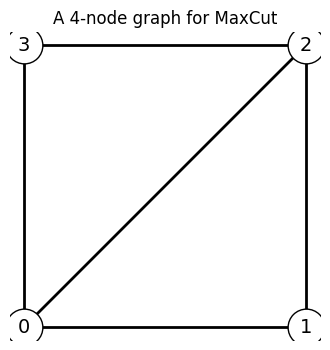

Edges: [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Four vertices and five unweighted edges.
# This is a square plus one diagonal.
n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]

# Fixed 2D coordinates for drawing.
positions = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])

plt.figure(figsize=(4, 4))

for i, j in edges:
    x_values = [positions[i, 0], positions[j, 0]]
    y_values = [positions[i, 1], positions[j, 1]]
    plt.plot(x_values, y_values, color="black", linewidth=2)

for vertex in range(n):
    plt.scatter(positions[vertex, 0], positions[vertex, 1], s=700, color="white", edgecolor="black", zorder=3)
    plt.text(positions[vertex, 0], positions[vertex, 1], str(vertex), ha="center", va="center", fontsize=14, zorder=4)

plt.title("A 4-node graph for MaxCut")
plt.axis("equal")
plt.axis("off")
plt.show()

print("Edges:", edges)

## 3. Enumerate all bit strings

For `n = 4`, there are `2^n = 16` bit strings. Each bit string corresponds to one computational basis state.

In [19]:
import numpy as np

n = 4
dimension = 2 ** n

# Each bit string labels one computational basis state |x>.
bit_strings = []
for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

print("Number of qubits n =", n)
print("Hilbert space dimension = 2^n =", dimension)
print()
print("Computational basis states:")

for bits in bit_strings:
    print(bits)

Number of qubits n = 4
Hilbert space dimension = 2^n = 16

Computational basis states:
0000
0001
0010
0011
0100
0101
0110
0111
1000
1001
1010
1011
1100
1101
1110
1111


## 4. Compute the classical MaxCut value

For a bit string `x`, the MaxCut variables are `x_i ∈ {0,1}`. We map them to spin variables using `z_i = (-1)^x_i` and compute

$$C(x) = \frac{1}{2}\sum_{(i,j)\in E}(1 - z_i z_j).$$

In [20]:
import numpy as np

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
for k in range(dimension):
    bit_strings.append(format(k, "0" + str(n) + "b"))

cut_values = []

for bits in bit_strings:
    x = np.array([int(character) for character in bits])

    # Spin variable used in the lecture: z_i = (-1)^x_i.
    z = (-1) ** x

    # Cost term for one edge: (1 - z_i z_j) / 2.
    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)
    print("x =", bits, "  z =", z.tolist(), "  C(x) =", int(cut_value))

maximum_cut_value = max(cut_values)
best_bit_strings = []

for index in range(dimension):
    if cut_values[index] == maximum_cut_value:
        best_bit_strings.append(bit_strings[index])

print()
print("Maximum cut value:", int(maximum_cut_value))
print("Best bit strings:", best_bit_strings)

x = 0000   z = [1, 1, 1, 1]   C(x) = 0
x = 0001   z = [1, 1, 1, -1]   C(x) = 2
x = 0010   z = [1, 1, -1, 1]   C(x) = 3
x = 0011   z = [1, 1, -1, -1]   C(x) = 3
x = 0100   z = [1, -1, 1, 1]   C(x) = 2
x = 0101   z = [1, -1, 1, -1]   C(x) = 4
x = 0110   z = [1, -1, -1, 1]   C(x) = 3
x = 0111   z = [1, -1, -1, -1]   C(x) = 3
x = 1000   z = [-1, 1, 1, 1]   C(x) = 3
x = 1001   z = [-1, 1, 1, -1]   C(x) = 3
x = 1010   z = [-1, 1, -1, 1]   C(x) = 4
x = 1011   z = [-1, 1, -1, -1]   C(x) = 2
x = 1100   z = [-1, -1, 1, 1]   C(x) = 3
x = 1101   z = [-1, -1, 1, -1]   C(x) = 3
x = 1110   z = [-1, -1, -1, 1]   C(x) = 2
x = 1111   z = [-1, -1, -1, -1]   C(x) = 0

Maximum cut value: 4
Best bit strings: ['0101', '1010']


## 5. Visualize all cut values

The classical objective landscape assigns one number `C(x)` to each bit string.

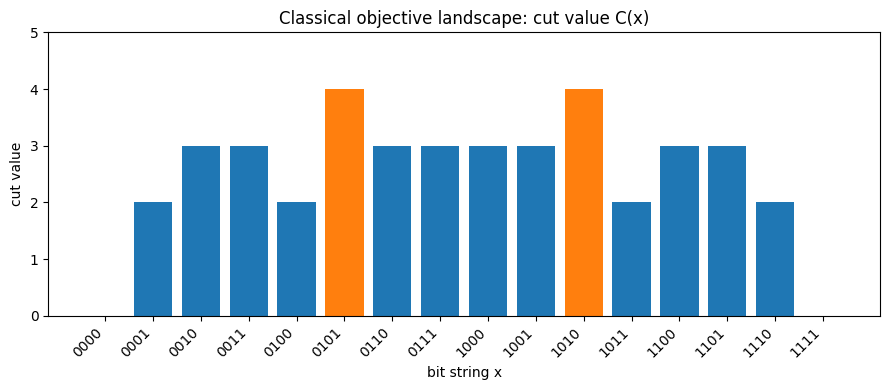

In [21]:
import numpy as np
import matplotlib.pyplot as plt

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

maximum_cut_value = max(cut_values)
colors = []
for value in cut_values:
    if value == maximum_cut_value:
        colors.append("tab:orange")
    else:
        colors.append("tab:blue")

plt.figure(figsize=(9, 4))
plt.bar(bit_strings, cut_values, color=colors)
plt.title("Classical objective landscape: cut value C(x)")
plt.xlabel("bit string x")
plt.ylabel("cut value")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(cut_values) + 1)
plt.tight_layout()
plt.show()

## 6. Build the explicit diagonal Hamiltonian

For MaxCut, the cost Hamiltonian is diagonal in the computational basis:

$$H_C = \frac{1}{2}\sum_{(i,j)\in E}(I - Z_i Z_j).$$

The diagonal entry for basis state `|x⟩` is exactly `C(x)`.

Shape of H_C: (16, 16)
Diagonal values:
[0. 2. 3. 3. 2. 4. 3. 3. 3. 3. 4. 2. 3. 3. 2. 0.]


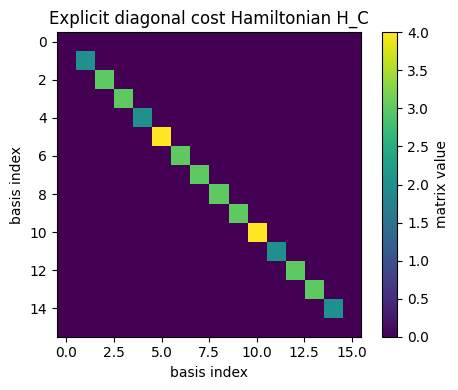

In [22]:
import numpy as np
import matplotlib.pyplot as plt

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

# This explicit construction is pedagogical but does not scale.
H_C = np.zeros((dimension, dimension))
for index in range(dimension):
    H_C[index, index] = cut_values[index]

print("Shape of H_C:", H_C.shape)
print("Diagonal values:")
print(np.diag(H_C))

plt.figure(figsize=(5, 4))
plt.imshow(H_C, cmap="viridis")
plt.colorbar(label="matrix value")
plt.title("Explicit diagonal cost Hamiltonian H_C")
plt.xlabel("basis index")
plt.ylabel("basis index")
plt.tight_layout()
plt.show()

## 7. Why the Hamiltonian is `2^n × 2^n`

An `n`-qubit state vector has `2^n` amplitudes. An explicit operator acting on that state vector is therefore a `2^n × 2^n` matrix.

 n   dimension  matrix entries
 1          2               4
 2          4              16
 3          8              64
 4         16             256
 5         32            1024
 6         64            4096
 7        128           16384
 8        256           65536
 9        512          262144
10       1024         1048576
11       2048         4194304
12       4096        16777216


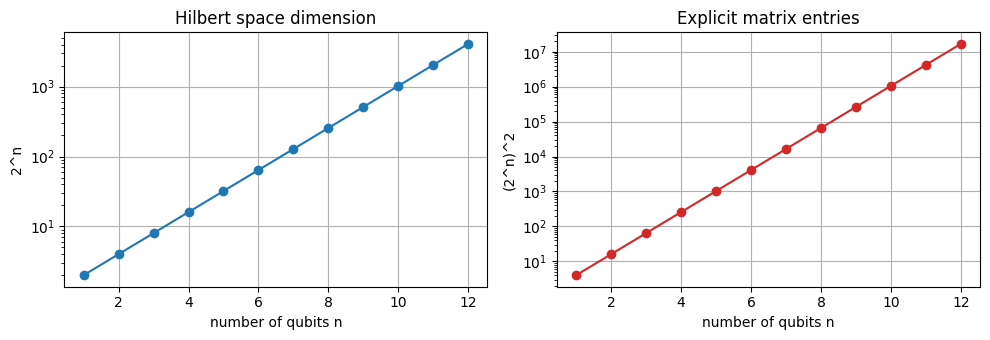

In [23]:
import numpy as np
import matplotlib.pyplot as plt

n_values = np.arange(1, 13)
dimensions = 2 ** n_values
matrix_entries = dimensions ** 2

# Explicit state vectors and matrices grow exponentially with n.
print(" n   dimension  matrix entries")
for index in range(len(n_values)):
    print(f"{n_values[index]:2d} {dimensions[index]:10d} {matrix_entries[index]:15d}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(n_values, dimensions, marker="o")
axes[0].set_title("Hilbert space dimension")
axes[0].set_xlabel("number of qubits n")
axes[0].set_ylabel("2^n")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].plot(n_values, matrix_entries, marker="o", color="tab:red")
axes[1].set_title("Explicit matrix entries")
axes[1].set_xlabel("number of qubits n")
axes[1].set_ylabel("(2^n)^2")
axes[1].set_yscale("log")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Pauli-Z action on one qubit

The Pauli-Z operator has computational basis states as eigenvectors: `|0⟩` has eigenvalue `+1`, and `|1⟩` has eigenvalue `-1`.

In [24]:
import numpy as np

Z = np.array([
    [1, 0],
    [0, -1],
], dtype=complex)

ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)

print("Z |0> =", Z @ ket_0)
print("Z |1> =", Z @ ket_1)
print()
print("Eigenvalue interpretation:")
print("|0> -> +1")
print("|1> -> -1")

Z |0> = [1.+0.j 0.+0.j]
Z |1> = [ 0.+0.j -1.+0.j]

Eigenvalue interpretation:
|0> -> +1
|1> -> -1


## 9. `Z_i Z_j` as a same/different detector

For two qubits, `Z ⊗ Z` returns eigenvalue `+1` when the two bits are equal and `-1` when they are different.

In [25]:
import numpy as np

I = np.eye(2, dtype=complex)
Z = np.array([
    [1, 0],
    [0, -1],
], dtype=complex)

ZZ = np.kron(Z, Z)

basis_labels = ["00", "01", "10", "11"]

for index in range(4):
    ket = np.zeros(4, dtype=complex)
    ket[index] = 1

    result = ZZ @ ket
    eigenvalue = result[index].real

    label = basis_labels[index]
    if label[0] == label[1]:
        relation = "equal"
    else:
        relation = "different"

    print("|" + label + ">", "eigenvalue =", int(eigenvalue), "bits are", relation)

print()
print("+1 means bits are equal")
print("-1 means bits are different")

|00> eigenvalue = 1 bits are equal
|01> eigenvalue = -1 bits are different
|10> eigenvalue = -1 bits are different
|11> eigenvalue = 1 bits are equal

+1 means bits are equal
-1 means bits are different


## 10. MaxCut edge indicator

For one edge `(a,b)`, the term `(1 - z_a z_b) / 2` is `1` exactly when the edge is cut.

In [26]:
print("a b  z_a z_b  z_a*z_b  indicator")

for a in [0, 1]:
    for b in [0, 1]:
        z_a = (-1) ** a
        z_b = (-1) ** b
        product = z_a * z_b
        indicator = (1 - product) / 2

        print(a, b, f"{z_a:4d}", f"{z_b:4d}", f"{product:8d}", f"{int(indicator):10d}")

print()
print("The indicator is 1 exactly when a and b are different.")
print("That is exactly when the edge crosses the cut.")

a b  z_a z_b  z_a*z_b  indicator
0 0    1    1        1          0
0 1    1   -1       -1          1
1 0   -1    1       -1          1
1 1   -1   -1        1          0

The indicator is 1 exactly when a and b are different.
That is exactly when the edge crosses the cut.


## 11. Validate `H_C |x⟩ = C(x) |x⟩`

This cell checks the central mapping directly for one example bit string.

In [27]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

H_C = np.zeros((dimension, dimension))
for index in range(dimension):
    H_C[index, index] = cut_values[index]

# Choose one basis state |x>.
example_bits = "0101"
basis_index = int(example_bits, 2)

ket_x = np.zeros(dimension)
ket_x[basis_index] = 1

left_side = H_C @ ket_x

# Compute C(x) again from the classical formula.
x = np.array([int(character) for character in example_bits])
z = (-1) ** x
classical_cut_value = 0.0
for i, j in edges:
    classical_cut_value = classical_cut_value + (1 - z[i] * z[j]) / 2

right_side = classical_cut_value * ket_x

print("Example bit string x =", example_bits)
print("C(x) =", int(classical_cut_value))
print()
print("H_C |x> =")
print(left_side)
print()
print("C(x) |x> =")
print(right_side)
print()
print("Are they equal?", np.allclose(left_side, right_side))

Example bit string x = 0101
C(x) = 4

H_C |x> =
[0. 0. 0. 0. 0. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

C(x) |x> =
[0. 0. 0. 0. 0. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Are they equal? True


## 12. Phase separator `U(C, γ)`

The phase separator applies

$$U(C,\gamma) = e^{-i\gamma H_C}.$$

Because `H_C` is diagonal, this multiplies each basis state by a phase depending on its cut value.

gamma = 0.7
Diagonal phases exp(-i gamma C(x)):
[ 1.   +0.j     0.17 -0.985j -0.505-0.863j -0.505-0.863j  0.17 -0.985j
 -0.942-0.335j -0.505-0.863j -0.505-0.863j -0.505-0.863j -0.505-0.863j
 -0.942-0.335j  0.17 -0.985j -0.505-0.863j -0.505-0.863j  0.17 -0.985j
  1.   +0.j   ]


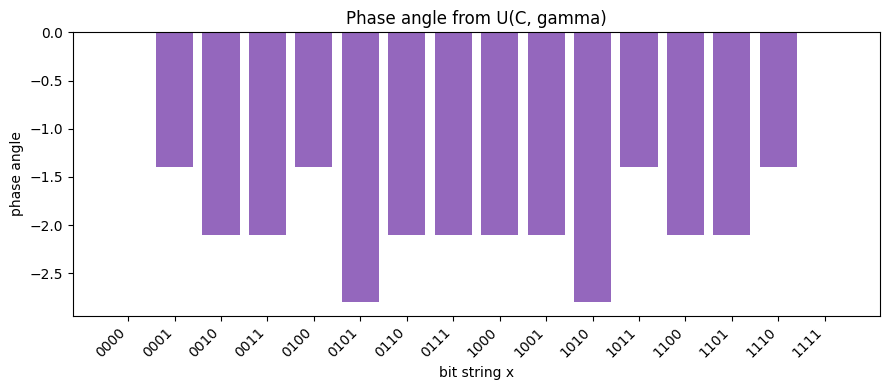

In [28]:
import numpy as np
import matplotlib.pyplot as plt

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n
gamma = 0.7

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

H_C = np.zeros((dimension, dimension))
for index in range(dimension):
    H_C[index, index] = cut_values[index]

# High-cost and low-cost states receive different phases.
diagonal_values = np.diag(H_C)
U_C = np.diag(np.exp(-1j * gamma * diagonal_values))
diagonal_phases = np.diag(U_C)

print("gamma =", gamma)
print("Diagonal phases exp(-i gamma C(x)):")
print(np.round(diagonal_phases, 3))

phase_angles = np.angle(diagonal_phases)

plt.figure(figsize=(9, 4))
plt.bar(bit_strings, phase_angles, color="tab:purple")
plt.title("Phase angle from U(C, gamma)")
plt.xlabel("bit string x")
plt.ylabel("phase angle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Mixer for one qubit

The QAOA mixer uses Pauli-X rotations. For one qubit,

$$e^{-i\beta X} = \cos(\beta)I - i\sin(\beta)X.$$

This moves amplitude between `|0⟩` and `|1⟩`.

In [29]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

I = np.eye(2, dtype=complex)
X = np.array([
    [0, 1],
    [1, 0],
], dtype=complex)

beta = 0.4
U_one_qubit = np.cos(beta) * I - 1j * np.sin(beta) * X

ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)

print("beta =", beta)
print()
print("Mixer matrix exp(-i beta X):")
print(U_one_qubit)
print()
print("Applied to |0>:")
print(U_one_qubit @ ket_0)
print()
print("Applied to |1>:")
print(U_one_qubit @ ket_1)
print()
print("The mixer moves amplitude between |0> and |1>.")

beta = 0.4

Mixer matrix exp(-i beta X):
[[0.921+0.j    0.   -0.389j]
 [0.   -0.389j 0.921+0.j   ]]

Applied to |0>:
[0.921+0.j    0.   -0.389j]

Applied to |1>:
[0.   -0.389j 0.921+0.j   ]

The mixer moves amplitude between |0> and |1>.


## 14. Build the p=1 QAOA state explicitly

For `p=1`, the lecture state is

$$|\gamma,\beta\rangle = U(B,\beta)U(C,\gamma)|s\rangle.$$

Here `|s⟩` is the uniform superposition over all bit strings.

gamma = 0.8
beta  = 0.4

bit string   C(x)   probability
0000         0      0.0504
0001         2      0.0034
0010         3      0.0469
0011         3      0.0894
0100         2      0.0034
0101         4      0.1700
0110         3      0.0894
0111         3      0.0469
1000         3      0.0469
1001         3      0.0894
1010         4      0.1700
1011         2      0.0034
1100         3      0.0894
1101         3      0.0469
1110         2      0.0034
1111         0      0.0504


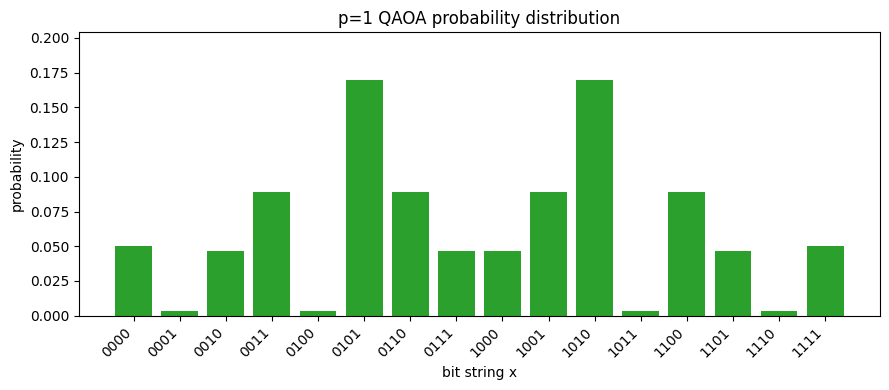

In [30]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n
gamma = 0.8
beta = 0.4

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

# Initial state |s>: equal amplitude on all computational basis states.
s = np.ones(dimension, dtype=complex) / np.sqrt(dimension)

# Phase separator U(C, gamma).
U_C = np.diag(np.exp(-1j * gamma * np.array(cut_values)))

# Mixer U(B, beta): tensor product of one-qubit mixers.
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
U_one_qubit = np.cos(beta) * I - 1j * np.sin(beta) * X

U_B = U_one_qubit
for qubit in range(n - 1):
    U_B = np.kron(U_B, U_one_qubit)

# QAOA creates a probability distribution over candidate cuts.
state = U_B @ (U_C @ s)
probabilities = np.abs(state) ** 2

print("gamma =", gamma)
print("beta  =", beta)
print()
print("bit string   C(x)   probability")
for index in range(dimension):
    print(bit_strings[index], "       ", int(cut_values[index]), "    ", f"{probabilities[index]:.4f}")

plt.figure(figsize=(9, 4))
plt.bar(bit_strings, probabilities, color="tab:green")
plt.title("p=1 QAOA probability distribution")
plt.xlabel("bit string x")
plt.ylabel("probability")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(probabilities) * 1.2)
plt.tight_layout()
plt.show()

## 15. Compare manually chosen parameters

Different values of `γ` and `β` give different probability distributions and therefore different expected cut values.

In [31]:
import numpy as np

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

cut_values = np.array(cut_values)

parameter_pairs = [
    (0.2, 0.1),
    (0.7, 0.3),
    (1.2, 0.4),
    (2.0, 0.6),
    (2.8, 0.2),
]

print(" gamma   beta   expected cut value")

for gamma, beta in parameter_pairs:
    # Rebuild the p=1 QAOA state for this parameter pair.
    s = np.ones(dimension, dtype=complex) / np.sqrt(dimension)
    U_C = np.diag(np.exp(-1j * gamma * cut_values))

    I = np.eye(2, dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    U_one_qubit = np.cos(beta) * I - 1j * np.sin(beta) * X

    U_B = U_one_qubit
    for qubit in range(n - 1):
        U_B = np.kron(U_B, U_one_qubit)

    state = U_B @ (U_C @ s)
    probabilities = np.abs(state) ** 2

    expected_cut_value = np.sum(probabilities * cut_values)
    print(f"{gamma:6.2f} {beta:6.2f} {expected_cut_value:20.4f}")

 gamma   beta   expected cut value
  0.20   0.10               2.6827
  0.70   0.30               3.2063
  1.20   0.40               2.6384
  2.00   0.60               2.8774
  2.80   0.20               2.6105


## 16. Grid search over `γ` and `β` for p=1

For this small example we can scan a grid of parameters and plot the expected cut value.

Best gamma: 0.5759586531581287
Best beta: 0.3141592653589793
Best expected cut value: 3.236931434239304


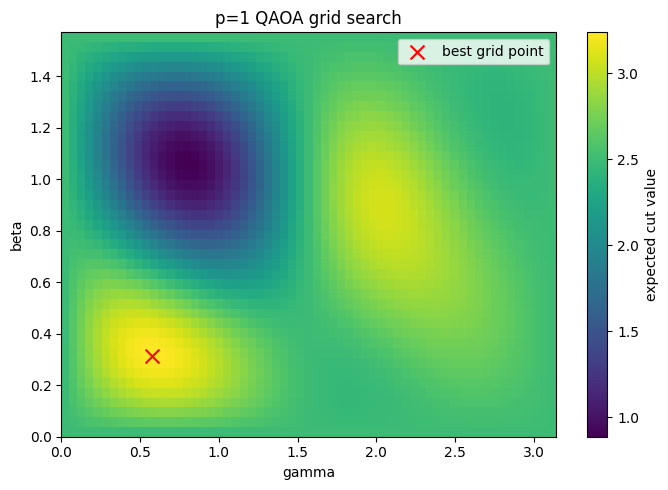

In [32]:
import numpy as np
import matplotlib.pyplot as plt

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

cut_values = np.array(cut_values)
s = np.ones(dimension, dtype=complex) / np.sqrt(dimension)

gamma_grid = np.linspace(0, np.pi, 61)
beta_grid = np.linspace(0, np.pi / 2, 41)
expected_values = np.zeros((len(beta_grid), len(gamma_grid)))

I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)

for beta_index in range(len(beta_grid)):
    beta = beta_grid[beta_index]

    U_one_qubit = np.cos(beta) * I - 1j * np.sin(beta) * X
    U_B = U_one_qubit
    for qubit in range(n - 1):
        U_B = np.kron(U_B, U_one_qubit)

    for gamma_index in range(len(gamma_grid)):
        gamma = gamma_grid[gamma_index]

        U_C = np.diag(np.exp(-1j * gamma * cut_values))
        state = U_B @ (U_C @ s)
        probabilities = np.abs(state) ** 2
        expected_values[beta_index, gamma_index] = np.sum(probabilities * cut_values)

best_indices = np.unravel_index(np.argmax(expected_values), expected_values.shape)
best_beta = beta_grid[best_indices[0]]
best_gamma = gamma_grid[best_indices[1]]
best_expectation = expected_values[best_indices]

print("Best gamma:", best_gamma)
print("Best beta:", best_beta)
print("Best expected cut value:", best_expectation)

plt.figure(figsize=(7, 5))
plt.imshow(
    expected_values,
    origin="lower",
    aspect="auto",
    extent=[gamma_grid[0], gamma_grid[-1], beta_grid[0], beta_grid[-1]],
    cmap="viridis",
)
plt.colorbar(label="expected cut value")
plt.scatter([best_gamma], [best_beta], color="red", marker="x", s=100, label="best grid point")
plt.title("p=1 QAOA grid search")
plt.xlabel("gamma")
plt.ylabel("beta")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Best p=1 distribution

Now we use the best grid point and inspect the probability distribution over bit strings.

Best gamma from grid: 0.5759586531581287
Best beta from grid: 0.3141592653589793

bit string   C(x)   probability
0000         0      0.0082
0001         2      0.0109
0010         3      0.0564
0011         3      0.0961
0100         2      0.0109
0101         4      0.1649
0110         3      0.0961
0111         3      0.0564
1000         3      0.0564
1001         3      0.0961
1010         4      0.1649
1011         2      0.0109
1100         3      0.0961
1101         3      0.0564
1110         2      0.0109
1111         0      0.0082

Most likely bit strings: ['0101', '1010']
0101 has cut value 4
1010 has cut value 4

True classical optimum: 4
Classically optimal bit strings: ['0101', '1010']


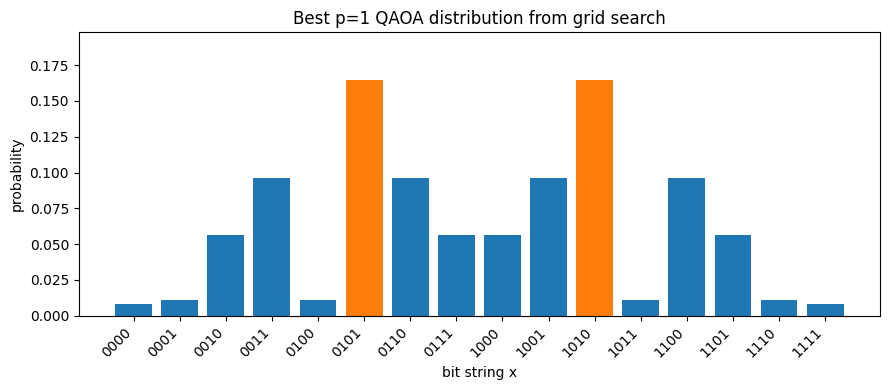

In [33]:
import numpy as np
import matplotlib.pyplot as plt

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

cut_values = np.array(cut_values)
s = np.ones(dimension, dtype=complex) / np.sqrt(dimension)

# Find the best grid point again so this cell is self-contained.
gamma_grid = np.linspace(0, np.pi, 61)
beta_grid = np.linspace(0, np.pi / 2, 41)
expected_values = np.zeros((len(beta_grid), len(gamma_grid)))

I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)

for beta_index in range(len(beta_grid)):
    beta = beta_grid[beta_index]
    U_one_qubit = np.cos(beta) * I - 1j * np.sin(beta) * X

    U_B = U_one_qubit
    for qubit in range(n - 1):
        U_B = np.kron(U_B, U_one_qubit)

    for gamma_index in range(len(gamma_grid)):
        gamma = gamma_grid[gamma_index]
        U_C = np.diag(np.exp(-1j * gamma * cut_values))
        state = U_B @ (U_C @ s)
        probabilities = np.abs(state) ** 2
        expected_values[beta_index, gamma_index] = np.sum(probabilities * cut_values)

best_indices = np.unravel_index(np.argmax(expected_values), expected_values.shape)
best_beta = beta_grid[best_indices[0]]
best_gamma = gamma_grid[best_indices[1]]

# Recompute the QAOA state at the best grid point.
U_C = np.diag(np.exp(-1j * best_gamma * cut_values))
U_one_qubit = np.cos(best_beta) * I - 1j * np.sin(best_beta) * X

U_B = U_one_qubit
for qubit in range(n - 1):
    U_B = np.kron(U_B, U_one_qubit)

state = U_B @ (U_C @ s)
probabilities = np.abs(state) ** 2

maximum_cut_value = max(cut_values)
classical_best_bit_strings = []
for index in range(dimension):
    if cut_values[index] == maximum_cut_value:
        classical_best_bit_strings.append(bit_strings[index])

largest_probability = max(probabilities)
most_likely_bit_strings = []
for index in range(dimension):
    if np.isclose(probabilities[index], largest_probability):
        most_likely_bit_strings.append(bit_strings[index])

print("Best gamma from grid:", best_gamma)
print("Best beta from grid:", best_beta)
print()
print("bit string   C(x)   probability")
for index in range(dimension):
    print(bit_strings[index], "       ", int(cut_values[index]), "    ", f"{probabilities[index]:.4f}")

print()
print("Most likely bit strings:", most_likely_bit_strings)
for bits in most_likely_bit_strings:
    index = int(bits, 2)
    print(bits, "has cut value", int(cut_values[index]))

print()
print("True classical optimum:", int(maximum_cut_value))
print("Classically optimal bit strings:", classical_best_bit_strings)

colors = []
for value in cut_values:
    if value == maximum_cut_value:
        colors.append("tab:orange")
    else:
        colors.append("tab:blue")

plt.figure(figsize=(9, 4))
plt.bar(bit_strings, probabilities, color=colors)
plt.title("Best p=1 QAOA distribution from grid search")
plt.xlabel("bit string x")
plt.ylabel("probability")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(probabilities) * 1.2)
plt.tight_layout()
plt.show()

## 18. Sampling simulation

A state-vector simulator gives the full probability distribution. Real quantum hardware gives measurement samples.

Number of measurements: 1000
Best gamma from grid: 0.5759586531581287
Best beta from grid: 0.3141592653589793
Best sampled bit string: 0101
Cut value of best sampled bit string: 4


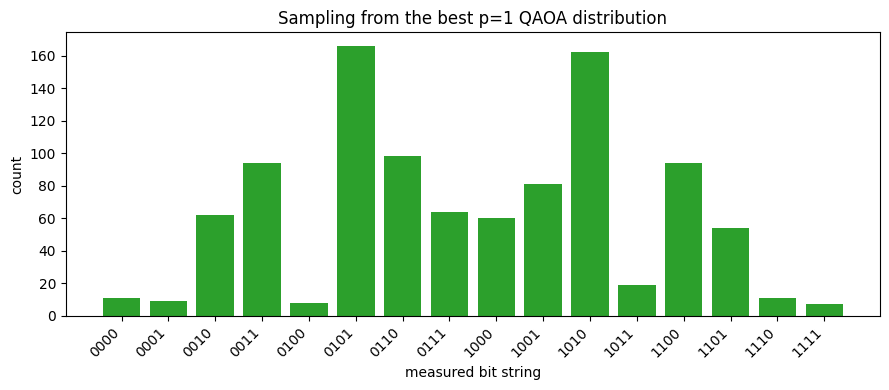

In [34]:
import numpy as np
import matplotlib.pyplot as plt

n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
dimension = 2 ** n

bit_strings = []
cut_values = []

for k in range(dimension):
    bits = format(k, "0" + str(n) + "b")
    bit_strings.append(bits)

    x = np.array([int(character) for character in bits])
    z = (-1) ** x

    cut_value = 0.0
    for i, j in edges:
        cut_value = cut_value + (1 - z[i] * z[j]) / 2

    cut_values.append(cut_value)

cut_values = np.array(cut_values)
s = np.ones(dimension, dtype=complex) / np.sqrt(dimension)

# Find the best p=1 grid point inside this cell.
gamma_grid = np.linspace(0, np.pi, 61)
beta_grid = np.linspace(0, np.pi / 2, 41)
expected_values = np.zeros((len(beta_grid), len(gamma_grid)))

I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)

for beta_index in range(len(beta_grid)):
    beta = beta_grid[beta_index]
    U_one_qubit = np.cos(beta) * I - 1j * np.sin(beta) * X

    U_B = U_one_qubit
    for qubit in range(n - 1):
        U_B = np.kron(U_B, U_one_qubit)

    for gamma_index in range(len(gamma_grid)):
        gamma = gamma_grid[gamma_index]
        U_C = np.diag(np.exp(-1j * gamma * cut_values))
        state = U_B @ (U_C @ s)
        probabilities = np.abs(state) ** 2
        expected_values[beta_index, gamma_index] = np.sum(probabilities * cut_values)

best_indices = np.unravel_index(np.argmax(expected_values), expected_values.shape)
best_beta = beta_grid[best_indices[0]]
best_gamma = gamma_grid[best_indices[1]]

# Build the best p=1 probability distribution.
U_C = np.diag(np.exp(-1j * best_gamma * cut_values))
U_one_qubit = np.cos(best_beta) * I - 1j * np.sin(best_beta) * X

U_B = U_one_qubit
for qubit in range(n - 1):
    U_B = np.kron(U_B, U_one_qubit)

state = U_B @ (U_C @ s)
probabilities = np.abs(state) ** 2

# Real quantum hardware gives samples, not the full state vector.
np.random.seed(7)
number_of_shots = 1000
samples = np.random.choice(dimension, size=number_of_shots, p=probabilities)
sample_counts = np.bincount(samples, minlength=dimension)

best_sampled_index = 0
best_sampled_cut_value = -1
for index in range(dimension):
    if sample_counts[index] > 0 and cut_values[index] > best_sampled_cut_value:
        best_sampled_index = index
        best_sampled_cut_value = cut_values[index]

print("Number of measurements:", number_of_shots)
print("Best gamma from grid:", best_gamma)
print("Best beta from grid:", best_beta)
print("Best sampled bit string:", bit_strings[best_sampled_index])
print("Cut value of best sampled bit string:", int(best_sampled_cut_value))

plt.figure(figsize=(9, 4))
plt.bar(bit_strings, sample_counts, color="tab:green")
plt.title("Sampling from the best p=1 QAOA distribution")
plt.xlabel("measured bit string")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 19. Final message

- MaxCut can be written as a diagonal Hamiltonian.
- Computational basis states correspond to candidate solutions.
- The cost Hamiltonian gives each candidate solution its objective value.
- QAOA alternates phase separation and mixing.
- The classical optimizer tunes `γ` and `β`.
- Measurement returns candidate solutions probabilistically.
- Small examples are pedagogical; the open question is whether shallow circuits help for useful large instances.